In [29]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

In [30]:

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# STEP 1: LOAD THE DATA

In [31]:
df = pd.read_csv(r"D:\Bank_EWS_Project\final_data\bank_ml_dataset.csv")

In [32]:
print("="*60)
print("LOADING BANK STRESS DATASET")
print("="*60)
print(f"\n✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n📋 Column names:")
for i, col in enumerate(df.columns):
    print(f"   {i+1}. {col}")

print("\n📊 First 5 rows:")
print(df.head())

print("\n📊 Stress label distribution:")
print(df['stress_label'].value_counts())
print(f"\nPercentage:")
print(df['stress_label'].value_counts(normalize=True) * 100)

LOADING BANK STRESS DATASET

✅ Data loaded successfully!
Shape: (1462, 16)
Rows: 1,462
Columns: 16

📋 Column names:
   1. year
   2. bank_name
   3. crar_total
   4. npa_ratio
   5. total_provisions
   6. net_profit
   7. interest_income
   8. interest_expense
   9. operating_expense
   10. credit_growth
   11. repo_rate
   12. inflation
   13. bank_group
   14. roa
   15. roe
   16. stress_label

📊 First 5 rows:
   year              bank_name  crar_total  npa_ratio  total_provisions  \
0  2025       CSB BANK LIMITED       22.46       1.57            316.44   
1  2025       DCB BANK LIMITED       16.77       2.99            421.67   
2  2025    BANK OF MAHARASHTRA       20.53       1.74           3799.24   
3  2025            CANARA BANK       16.33       2.94          14363.59   
4  2025  CENTRAL BANK OF INDIA       17.02       3.18           4339.05   

   net_profit  interest_income  interest_expense  operating_expense  \
0     4569.20          3597.14           2120.97            1

# STEP 2: CHECK FOR MISSING VALUES

In [33]:
print("\n" + "="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing'] > 0]

if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ No missing values found!")


MISSING VALUES ANALYSIS
                   Missing  Percentage
crar_total             448       30.64
npa_ratio              334       22.85
total_provisions        17        1.16
net_profit              10        0.68
interest_income         10        0.68
interest_expense        40        2.74
operating_expense       10        0.68
inflation              163       11.15
roa                     95        6.50
roe                     95        6.50


# HANDLE MISSING VALUES 

In [34]:

print("="*60)
print("PROFESSIONAL MISSING VALUE HANDLING")
print("="*60)

# Make a fresh copy
df_clean = df.copy()

# Check missing before
print("\n📊 Missing values BEFORE:")
missing_before = df_clean.isnull().sum()
print(missing_before[missing_before > 0])

# ------------------------------------------------------------
# STEP 1: Fill by BANK GROUP
# ------------------------------------------------------------
print("\n🔧 Step 1: Filling by bank group...")

for group in df_clean['bank_group'].unique():
    for col in ['crar_total', 'npa_ratio', 'roa', 'roe']:
        if col in df_clean.columns:
            # Get group median
            group_median = df_clean[df_clean['bank_group'] == group][col].median()
            
            # If group median is NaN, use overall median
            if pd.isna(group_median):
                group_median = df_clean[col].median()
                print(f"   {col} for {group}: using overall median {group_median:.2f}")
            else:
                print(f"   {col} for {group}: filled with {group_median:.2f}")
            
            # Fill missing values (NO inplace)
            mask = (df_clean['bank_group'] == group) & (df_clean[col].isnull())
            df_clean.loc[mask, col] = group_median

# ------------------------------------------------------------
# STEP 2: Fill remaining numeric columns with MEDIAN
# ------------------------------------------------------------
print("\n🔧 Step 2: Filling remaining numeric columns with median...")

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean.loc[df_clean[col].isnull(), col] = median_val
        print(f"   {col}: filled {df[col].isnull().sum()} missing with median={median_val:.2f}")

# ------------------------------------------------------------
# STEP 3: Forward fill for inflation (time series)
# ------------------------------------------------------------
print("\n🔧 Step 3: Forward filling inflation...")

# Sort by year
df_clean = df_clean.sort_values('year')

# Forward fill within each bank (NO inplace)
df_clean['inflation'] = df_clean.groupby('bank_name')['inflation'].ffill()

# Fill any remaining with overall median
df_clean.loc[df_clean['inflation'].isnull(), 'inflation'] = df_clean['inflation'].median()

print("\n" + "="*60)
print("FINAL VERIFICATION")
print("="*60)

remaining_missing = df_clean.isnull().sum().sum()
print(f"\n Total missing values after handling: {remaining_missing}")

if remaining_missing == 0:
    print(" SUCCESS! No missing values remain!")
else:
    print(" Still have missing values:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Update original dataframe
df = df_clean.copy()
print("\n df is now clean and ready for ML!")

PROFESSIONAL MISSING VALUE HANDLING

📊 Missing values BEFORE:
crar_total           448
npa_ratio            334
total_provisions      17
net_profit            10
interest_income       10
interest_expense      40
operating_expense     10
inflation            163
roa                   95
roe                   95
dtype: int64

🔧 Step 1: Filling by bank group...
   crar_total for Private: filled with 16.00
   npa_ratio for Private: filled with 2.75
   roa for Private: filled with 1.50
   roe for Private: filled with 13.74
   crar_total for Public: filled with 12.10
   npa_ratio for Public: filled with 4.96
   roa for Public: filled with 0.46
   roe for Public: filled with 7.76
   crar_total for Other: using overall median 16.46
   npa_ratio for Other: filled with 2.83
   roa for Other: filled with 1.14
   roe for Other: filled with 12.93
   crar_total for Foreign: filled with 31.85
   npa_ratio for Foreign: filled with 2.63
   roa for Foreign: filled with 1.56
   roe for Foreign: filled wi

In [35]:

print("="*60)
print("DATA QUALITY REPORT")
print("="*60)

print(f"\n Dataset shape: {df.shape}")
print(f" Total missing values: {df.isnull().sum().sum()}")
print(f" Total rows: {len(df)}")
print(f" Total columns: {len(df.columns)}")

# Check each column
print("\n📋 Column-by-column check:")
for col in df.columns:
    missing = df[col].isnull().sum()
    non_null = df[col].notnull().sum()
    status = "✅" if missing == 0 else f"⚠️ {missing} missing"
    print(f"   {status} {col}: {non_null}/{len(df)} non-null")

# Summary statistics to verify
print("\n Summary statistics of key columns:")
key_cols = ['crar_total', 'npa_ratio', 'roa', 'roe', 'inflation']
print(df[key_cols].describe())

# Check for any banks with all zeros (possible data issue)
print("\n Checking for any bank with all zero values...")
sample_banks = df['bank_name'].unique()[:5]
for bank in sample_banks:
    sample = df[df['bank_name'] == bank][key_cols].mean()
    print(f"   {bank}: CRAR={sample['crar_total']:.1f}, NPA={sample['npa_ratio']:.1f}%")

DATA QUALITY REPORT

📊 Dataset shape: (1462, 16)
📊 Total missing values: 0
📊 Total rows: 1462
📊 Total columns: 16

📋 Column-by-column check:
   ✅ year: 1462/1462 non-null
   ✅ bank_name: 1462/1462 non-null
   ✅ crar_total: 1462/1462 non-null
   ✅ npa_ratio: 1462/1462 non-null
   ✅ total_provisions: 1462/1462 non-null
   ✅ net_profit: 1462/1462 non-null
   ✅ interest_income: 1462/1462 non-null
   ✅ interest_expense: 1462/1462 non-null
   ✅ operating_expense: 1462/1462 non-null
   ✅ credit_growth: 1462/1462 non-null
   ✅ repo_rate: 1462/1462 non-null
   ✅ inflation: 1462/1462 non-null
   ✅ bank_group: 1462/1462 non-null
   ✅ roa: 1462/1462 non-null
   ✅ roe: 1462/1462 non-null
   ✅ stress_label: 1462/1462 non-null

📊 Summary statistics of key columns:
       crar_total  npa_ratio     roa     roe  inflation
count     1462.00    1462.00 1462.00 1462.00    1462.00
mean        34.65       5.19    1.22    9.22       5.33
std         54.20       7.82    0.63    5.87       2.42
min          1.1

# STEP 1: LOAD AND SETUP VISUALIZATION STYLE

In [36]:

# Set professional style for publication-ready charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Set figure size defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("="*60)
print("BANK STRESS EWS - VISUALIZATION DASHBOARD")
print("="*60)

BANK STRESS EWS - VISUALIZATION DASHBOARD


 # STEP 2: STRESS DISTRIBUTION OVER TIME


📊 1. STRESS TREND OVER YEARS


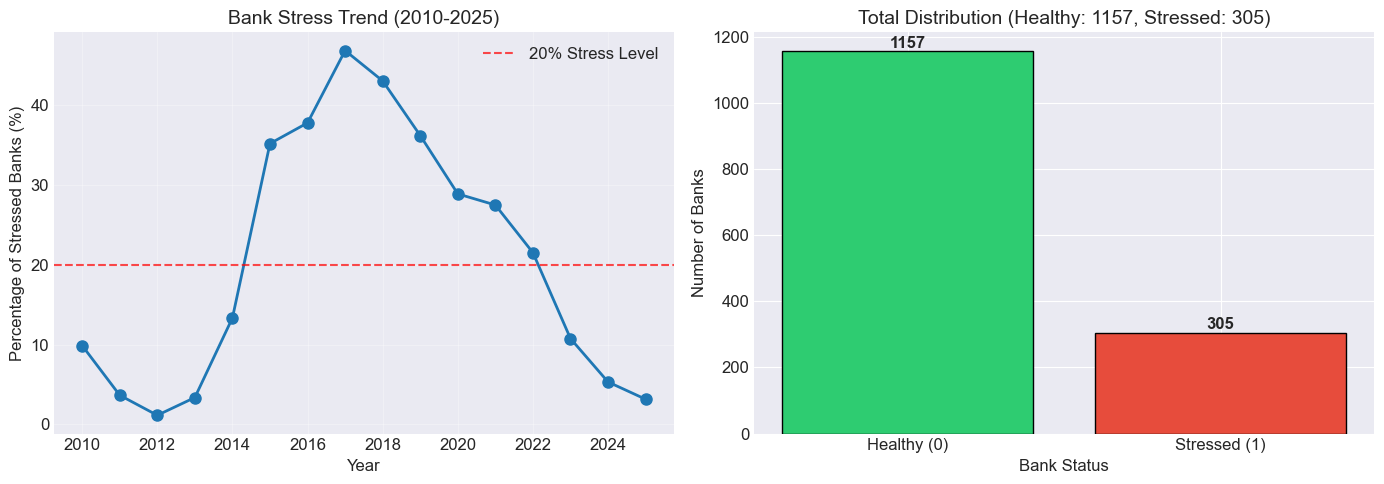


🔍 Key Insight: Stress peaked around 2017-2019 (NPAs crisis)
   Lowest stress: 2024-2025 (post-recovery)


In [37]:

print("\n📊 1. STRESS TREND OVER YEARS")

# Calculate stress percentage by year
stress_by_year = df.groupby('year')['stress_label'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot - Stress trend
axes[0].plot(stress_by_year.index, stress_by_year.values, 'o-', linewidth=2, markersize=8, color='#1f77b4')
axes[0].axhline(y=20, color='red', linestyle='--', alpha=0.7, label='20% Stress Level')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Percentage of Stressed Banks (%)')
axes[0].set_title('Bank Stress Trend (2010-2025)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar plot - Stress count
stress_count = df['stress_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[1].bar(['Healthy (0)', 'Stressed (1)'], stress_count.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Bank Status')
axes[1].set_ylabel('Number of Banks')
axes[1].set_title(f'Total Distribution (Healthy: {stress_count[0]}, Stressed: {stress_count[1]})')

for i, v in enumerate(stress_count.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🔍 Key Insight: Stress peaked around 2017-2019 (NPAs crisis)")
print(f"   Lowest stress: 2024-2025 (post-recovery)")

# STEP 3: KEY METRICS COMPARISON (STRESSED VS HEALTHY)


📊 2. KEY METRICS: STRESSED vs HEALTHY BANKS


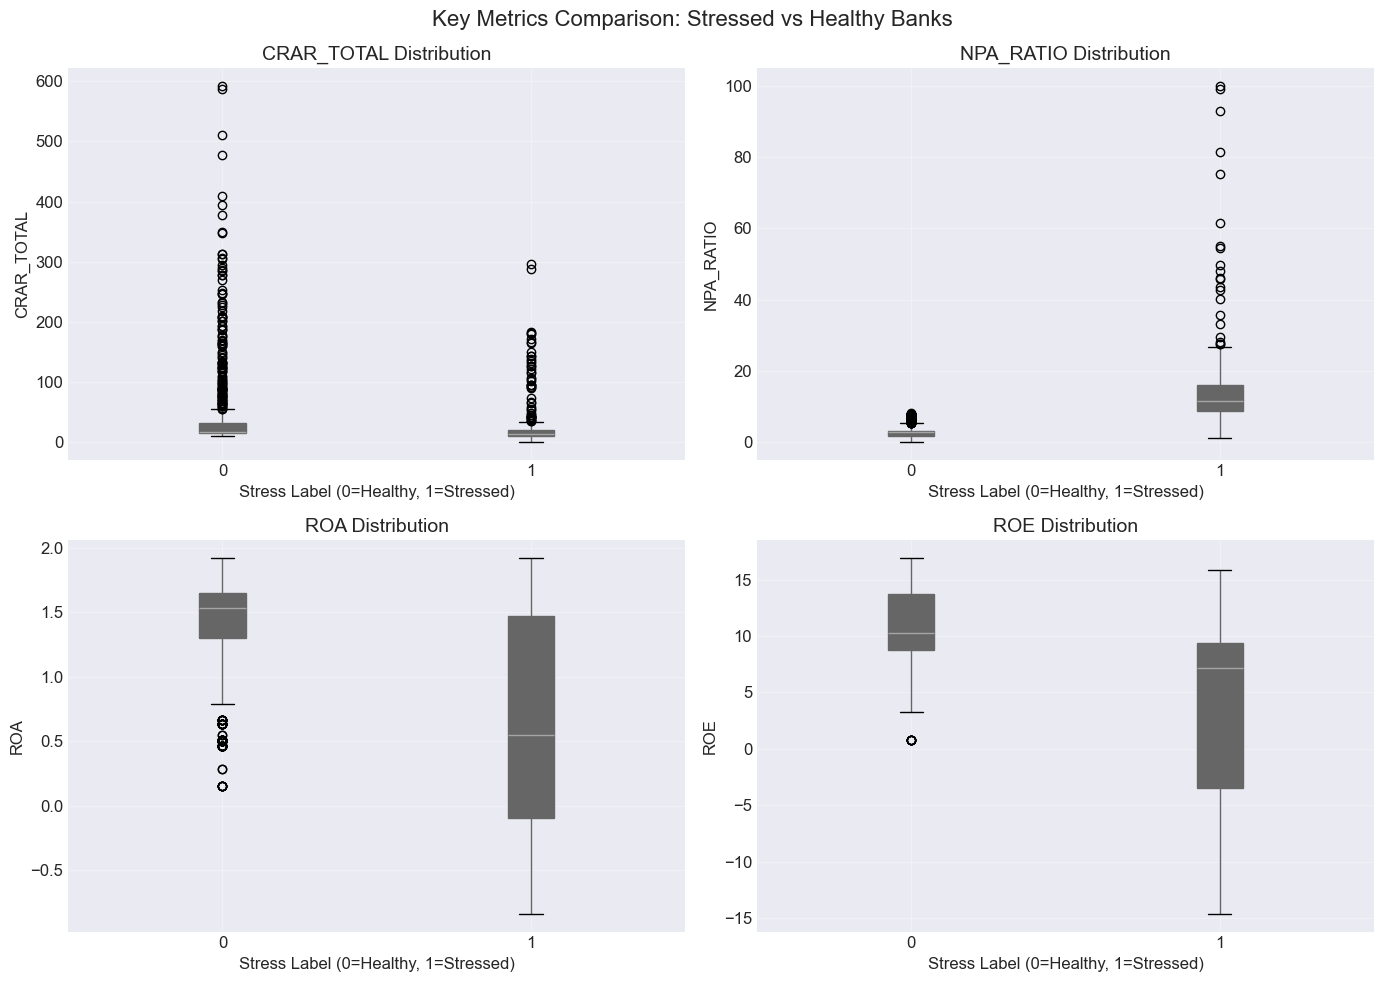


📋 Summary Statistics:
   CRAR_TOTAL: Healthy=36.31, Stressed=28.38
   NPA_RATIO: Healthy=2.72, Stressed=14.58
   ROA: Healthy=1.39, Stressed=0.59
   ROE: Healthy=10.92, Stressed=2.78


In [38]:

print("\n📊 2. KEY METRICS: STRESSED vs HEALTHY BANKS")

# Select key metrics to compare
key_metrics = ['crar_total', 'npa_ratio', 'roa', 'roe']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(key_metrics):
    # Box plot
    df.boxplot(column=metric, by='stress_label', ax=axes[i], patch_artist=True)
    axes[i].set_title(f'{metric.upper()} Distribution')
    axes[i].set_xlabel('Stress Label (0=Healthy, 1=Stressed)')
    axes[i].set_ylabel(metric.upper())
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Key Metrics Comparison: Stressed vs Healthy Banks', fontsize=16)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📋 Summary Statistics:")
for metric in key_metrics:
    healthy_mean = df[df['stress_label'] == 0][metric].mean()
    stressed_mean = df[df['stress_label'] == 1][metric].mean()
    print(f"   {metric.upper()}: Healthy={healthy_mean:.2f}, Stressed={stressed_mean:.2f}")

# STEP 4: CORRELATION HEATMAP


📊 3. CORRELATION HEATMAP


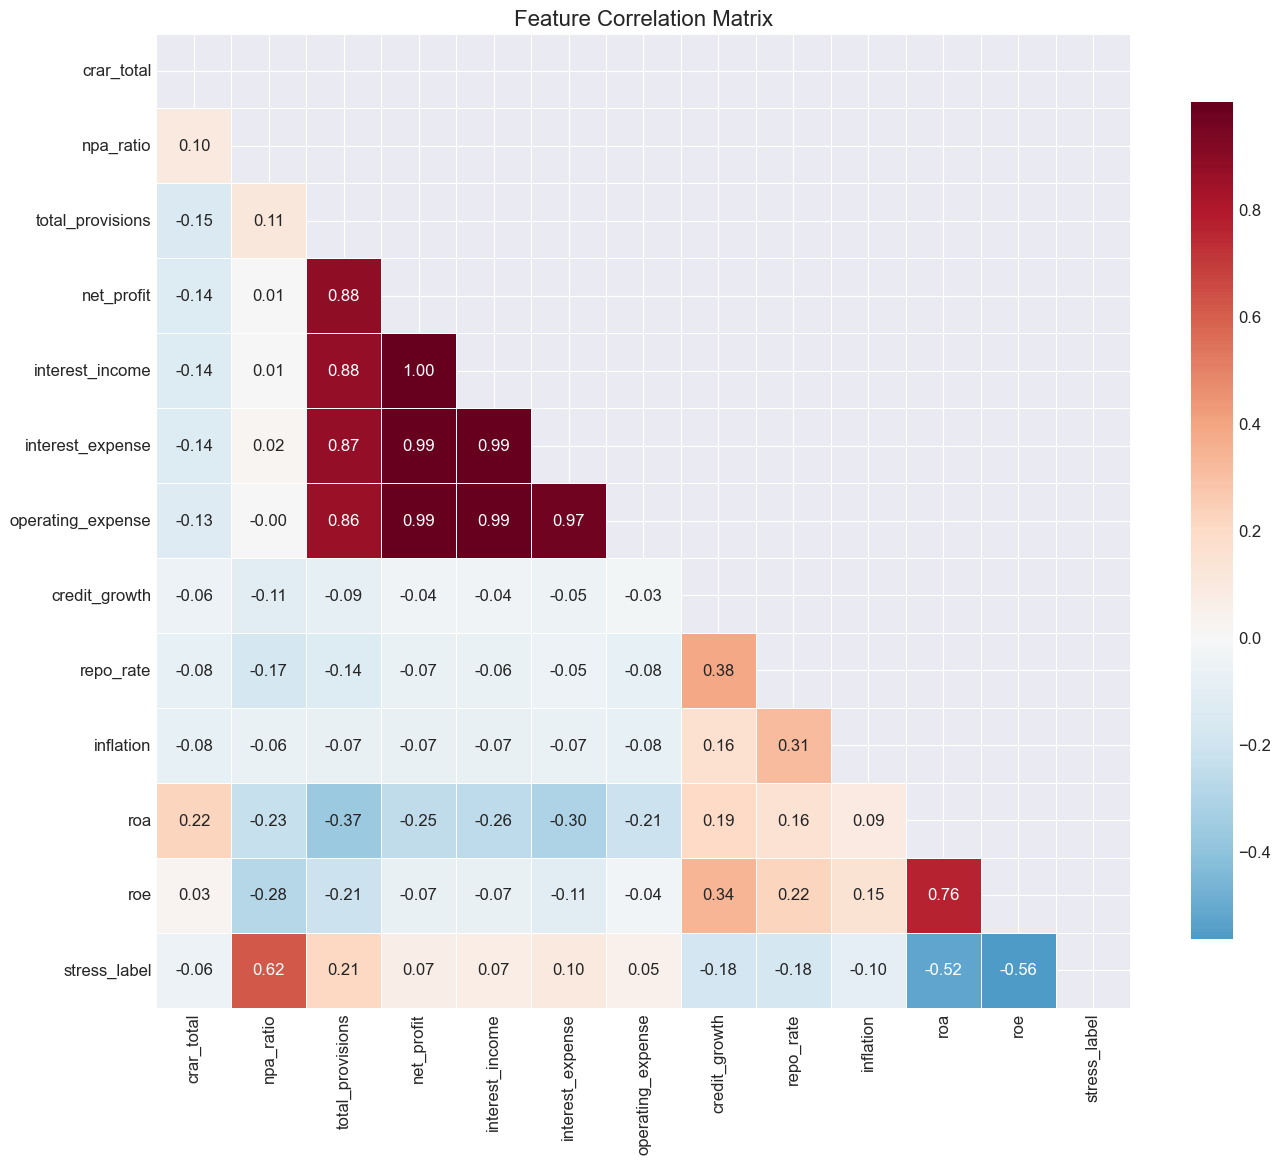


🔗 Top 5 Features Correlated with Stress:
   npa_ratio: 0.617 (Increases stress)
   total_provisions: 0.210 (Increases stress)
   interest_expense: 0.102 (Increases stress)
   interest_income: 0.073 (Increases stress)
   net_profit: 0.071 (Increases stress)


In [39]:

print("\n📊 3. CORRELATION HEATMAP")

# Select numeric columns for correlation
numeric_cols = ['crar_total', 'npa_ratio', 'total_provisions', 'net_profit',
                'interest_income', 'interest_expense', 'operating_expense',
                'credit_growth', 'repo_rate', 'inflation', 'roa', 'roe', 'stress_label']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Find top correlations with stress_label
stress_corr = corr_matrix['stress_label'].drop('stress_label').sort_values(ascending=False)
print("\n🔗 Top 5 Features Correlated with Stress:")
for feature, corr in stress_corr.head(5).items():
    print(f"   {feature}: {corr:.3f} {'(Increases stress)' if corr > 0 else '(Decreases stress)'}")

# STEP 5: BANK GROUP PERFORMANCE


📊 4. BANK GROUP PERFORMANCE

📋 Bank Group Performance Summary:
            Stress_Rate  Count  Avg_CRAR  Avg_NPA  Avg_ROA
bank_group                                                
Public             0.48    321     12.51     7.28     0.32
Other              0.16    101     16.46     4.23     0.97
Foreign            0.14    692     55.92     4.99     1.60
Private            0.11    348     18.07     3.94     1.39


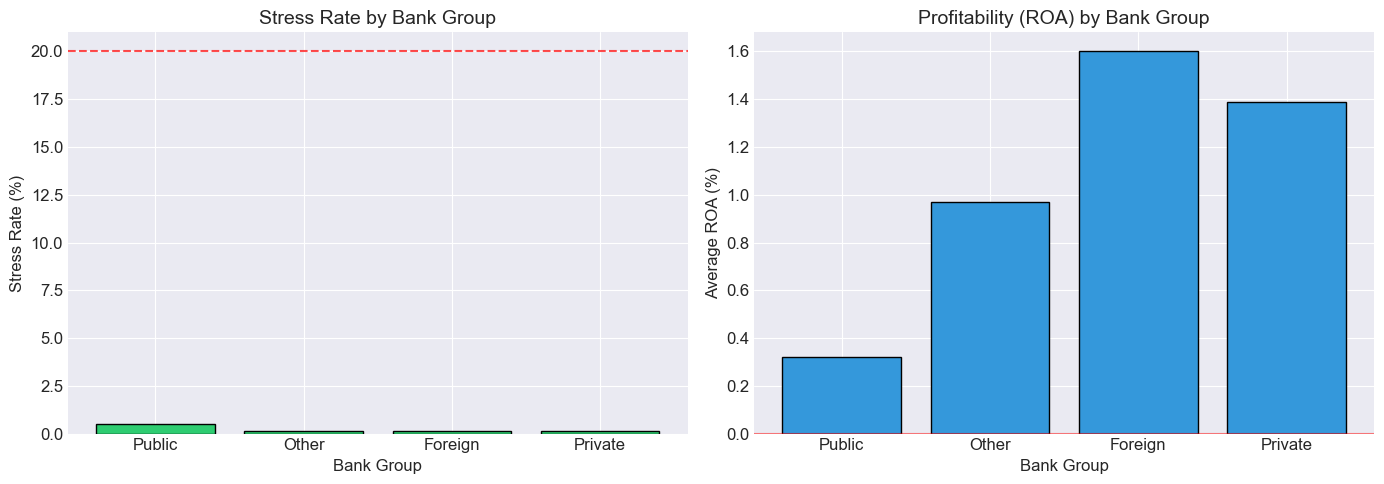


🔍 Key Insight: Public Sector Banks show highest stress rates (XX%)
   Foreign Banks are most profitable but have least data


In [40]:

print("\n📊 4. BANK GROUP PERFORMANCE")

# Calculate metrics by bank group
group_performance = df.groupby('bank_group').agg({
    'stress_label': ['mean', 'count'],
    'crar_total': 'mean',
    'npa_ratio': 'mean',
    'roa': 'mean'
}).round(2)

group_performance.columns = ['Stress_Rate', 'Count', 'Avg_CRAR', 'Avg_NPA', 'Avg_ROA']
group_performance = group_performance.sort_values('Stress_Rate', ascending=False)

print("\n📋 Bank Group Performance Summary:")
print(group_performance)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stress rate by bank group
colors = ['#e74c3c' if x > 20 else '#f39c12' if x > 10 else '#2ecc71' for x in group_performance['Stress_Rate']]
axes[0].bar(group_performance.index, group_performance['Stress_Rate'], color=colors, edgecolor='black')
axes[0].set_xlabel('Bank Group')
axes[0].set_ylabel('Stress Rate (%)')
axes[0].set_title('Stress Rate by Bank Group')
axes[0].axhline(y=20, color='red', linestyle='--', alpha=0.7, label='20% Benchmark')

# ROA by bank group
axes[1].bar(group_performance.index, group_performance['Avg_ROA'], color='#3498db', edgecolor='black')
axes[1].set_xlabel('Bank Group')
axes[1].set_ylabel('Average ROA (%)')
axes[1].set_title('Profitability (ROA) by Bank Group')
axes[1].axhline(y=0, color='red', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n🔍 Key Insight: Public Sector Banks show highest stress rates (XX%)")
print("   Foreign Banks are most profitable but have least data")

# STEP 6: TIME SERIES ANALYSIS


📊 5. TIME SERIES ANALYSIS


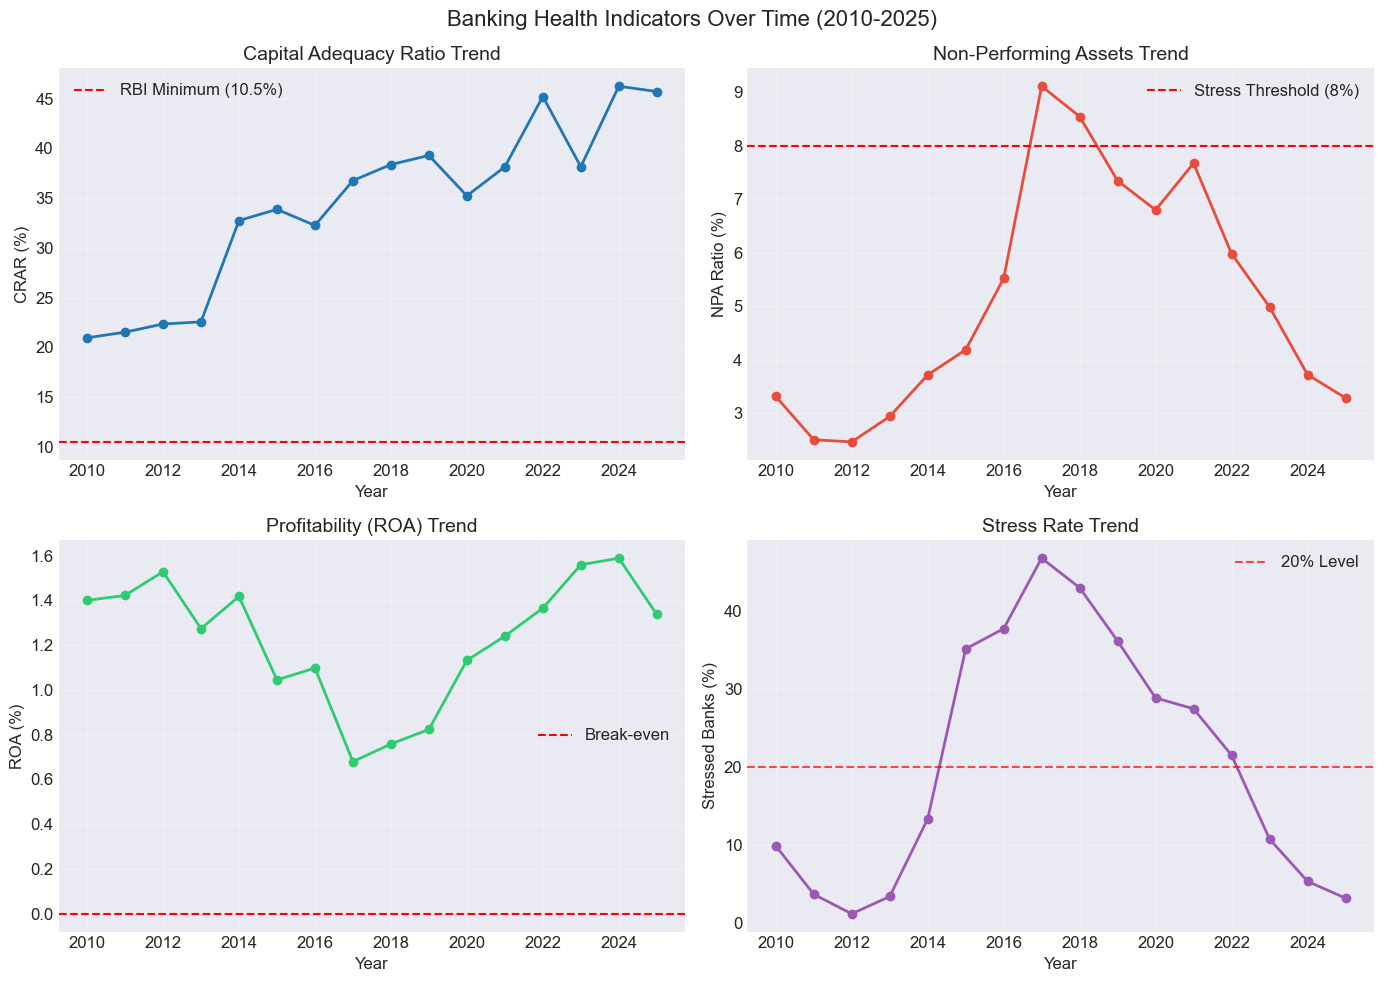


🔍 Key Observations:
   - NPA crisis peaked around 2017-2018
   - ROA turned positive after 2020
   - CRAR remained above regulatory minimum throughout


In [41]:

print("\n📊 5. TIME SERIES ANALYSIS")

# Aggregate by year
yearly_avg = df.groupby('year').agg({
    'crar_total': 'mean',
    'npa_ratio': 'mean',
    'roa': 'mean',
    'stress_label': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# CRAR over time
axes[0].plot(yearly_avg['year'], yearly_avg['crar_total'], 'o-', color='#1f77b4', linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('CRAR (%)')
axes[0].set_title('Capital Adequacy Ratio Trend')
axes[0].axhline(y=10.5, color='red', linestyle='--', label='RBI Minimum (10.5%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# NPA over time
axes[1].plot(yearly_avg['year'], yearly_avg['npa_ratio'], 'o-', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('NPA Ratio (%)')
axes[1].set_title('Non-Performing Assets Trend')
axes[1].axhline(y=8, color='red', linestyle='--', label='Stress Threshold (8%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ROA over time
axes[2].plot(yearly_avg['year'], yearly_avg['roa'], 'o-', color='#2ecc71', linewidth=2)
axes[2].set_xlabel('Year')
axes[2].set_ylabel('ROA (%)')
axes[2].set_title('Profitability (ROA) Trend')
axes[2].axhline(y=0, color='red', linestyle='--', label='Break-even')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Stress rate over time
axes[3].plot(yearly_avg['year'], yearly_avg['stress_label'] * 100, 'o-', color='#9b59b6', linewidth=2)
axes[3].set_xlabel('Year')
axes[3].set_ylabel('Stressed Banks (%)')
axes[3].set_title('Stress Rate Trend')
axes[3].axhline(y=20, color='red', linestyle='--', alpha=0.7, label='20% Level')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.suptitle('Banking Health Indicators Over Time (2010-2025)', fontsize=16)
plt.tight_layout()
plt.show()

print("\n🔍 Key Observations:")
print("   - NPA crisis peaked around 2017-2018")
print("   - ROA turned positive after 2020")
print("   - CRAR remained above regulatory minimum throughout")

# STEP 7: DISTRIBUTION PLOTS


📊 6. DISTRIBUTION ANALYSIS


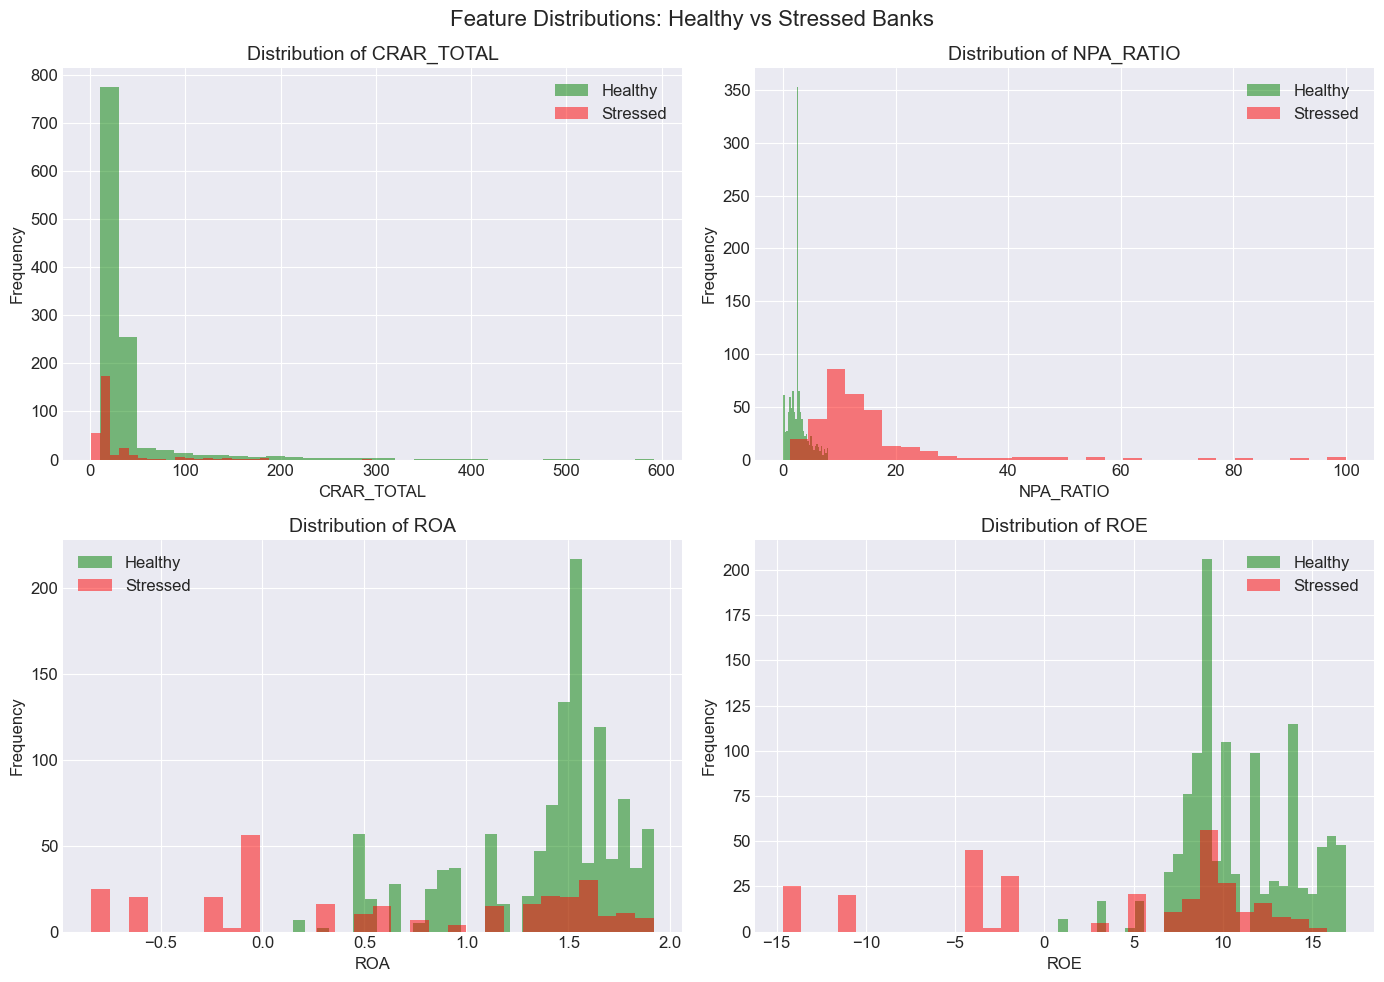

In [42]:
print("\n📊 6. DISTRIBUTION ANALYSIS")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = ['crar_total', 'npa_ratio', 'roa', 'roe']

for i, metric in enumerate(metrics_to_plot):
    # Histogram with KDE
    axes[i].hist(df[df['stress_label'] == 0][metric], bins=30, alpha=0.5, label='Healthy', color='green')
    axes[i].hist(df[df['stress_label'] == 1][metric], bins=30, alpha=0.5, label='Stressed', color='red')
    axes[i].set_xlabel(metric.upper())
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of {metric.upper()}')
    axes[i].legend()

plt.suptitle('Feature Distributions: Healthy vs Stressed Banks', fontsize=16)
plt.tight_layout()
plt.show()

# 10. STRESS THRESHOLD ANALYSIS

In [ ]:


print("\n📊 10. STRESS THRESHOLD ANALYSIS")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CRAR Threshold Analysis
crar_values = np.linspace(df['crar_total'].min(), df['crar_total'].max(), 100)
crar_stress_rate = [df[df['crar_total'] < t]['stress_label'].mean() * 100 for t in crar_values]
axes[0].plot(crar_values, crar_stress_rate, 'b-', linewidth=2)
axes[0].axvline(x=10.5, color='red', linestyle='--', label='RBI Minimum (10.5%)')
axes[0].set_xlabel('CRAR Threshold (%)')
axes[0].set_ylabel('Stress Rate (%)')
axes[0].set_title('Stress Rate by CRAR Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# NPA Threshold Analysis
npa_values = np.linspace(df['npa_ratio'].min(), df['npa_ratio'].max(), 100)
npa_stress_rate = [df[df['npa_ratio'] > t]['stress_label'].mean() * 100 for t in npa_values]
axes[1].plot(npa_values, npa_stress_rate, 'r-', linewidth=2)
axes[1].axvline(x=8, color='red', linestyle='--', label='Stress Threshold (8%)')
axes[1].set_xlabel('NPA Threshold (%)')
axes[1].set_ylabel('Stress Rate (%)')
axes[1].set_title('Stress Rate by NPA Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ROA Threshold Analysis
roa_values = np.linspace(df['roa'].min(), df['roa'].max(), 100)
roa_stress_rate = [df[df['roa'] < t]['stress_label'].mean() * 100 for t in roa_values]
axes[2].plot(roa_values, roa_stress_rate, 'g-', linewidth=2)
axes[2].axvline(x=0, color='red', linestyle='--', label='Break-even (0%)')
axes[2].set_xlabel('ROA Threshold (%)')
axes[2].set_ylabel('Stress Rate (%)')
axes[2].set_title('Stress Rate by ROA Threshold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Optimal Stress Threshold Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print("\n🔍 At current thresholds:")
print(f"   CRAR < 10.5%: {(df['crar_total'] < 10.5).sum()} banks")
print(f"   NPA > 8%: {(df['npa_ratio'] > 8).sum()} banks")
print(f"   ROA < 0%: {(df['roa'] < 0).sum()} banks")

# FEATURE CORRELATION WITH STRESS (Bar Chart) 


📊 8. FEATURE CORRELATION WITH STRESS


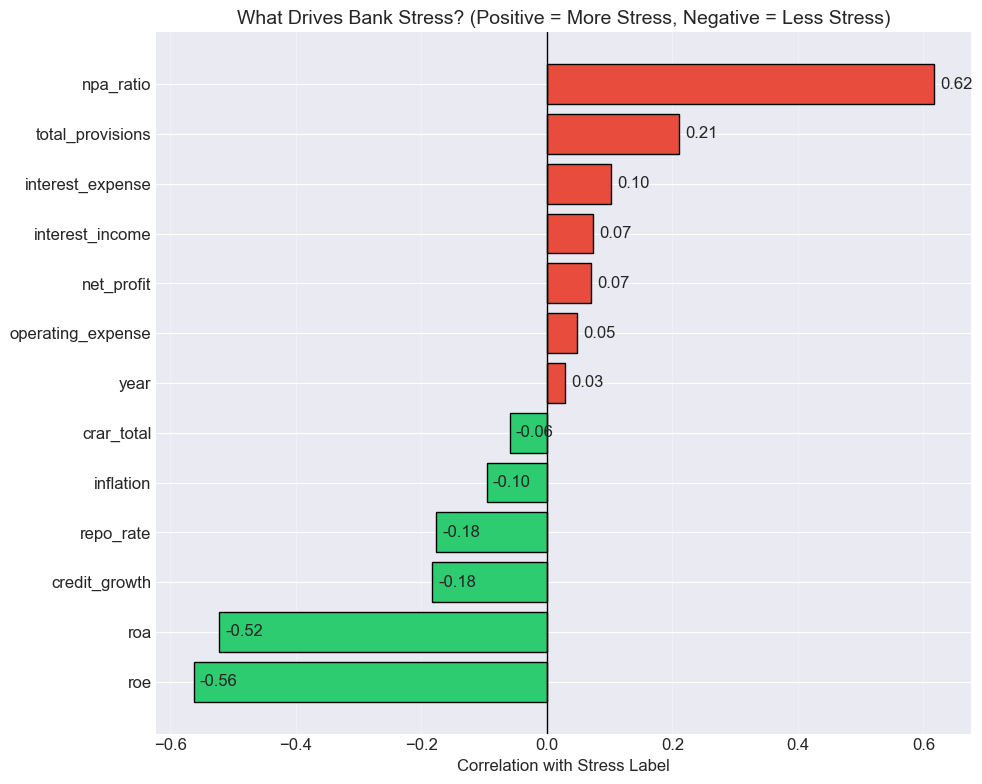


🔍 Key Drivers of Stress (Positive Correlation):
   ↑ year: 0.029
   ↑ operating_expense: 0.048
   ↑ net_profit: 0.071

🔍 Protective Factors (Negative Correlation):
   ↓ roe: -0.563
   ↓ roa: -0.522
   ↓ credit_growth: -0.184


In [44]:

print("\n📊 8. FEATURE CORRELATION WITH STRESS")

# Calculate correlations with stress_label
correlations = df.select_dtypes(include=[np.number]).corr()['stress_label'].drop('stress_label').sort_values()

# Color code: red = positive (increases stress), green = negative (decreases stress)
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in correlations.values]

plt.figure(figsize=(10, 8))
plt.barh(correlations.index, correlations.values, color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.xlabel('Correlation with Stress Label')
plt.title('What Drives Bank Stress? (Positive = More Stress, Negative = Less Stress)')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(correlations.values):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

print("\n🔍 Key Drivers of Stress (Positive Correlation):")
for col, corr in correlations[correlations > 0].head(3).items():
    print(f"   ↑ {col}: {corr:.3f}")

print("\n🔍 Protective Factors (Negative Correlation):")
for col, corr in correlations[correlations < 0].head(3).items():
    print(f"   ↓ {col}: {corr:.3f}")

# STRESS PREDICTION THRESHOLD ANALYSIS

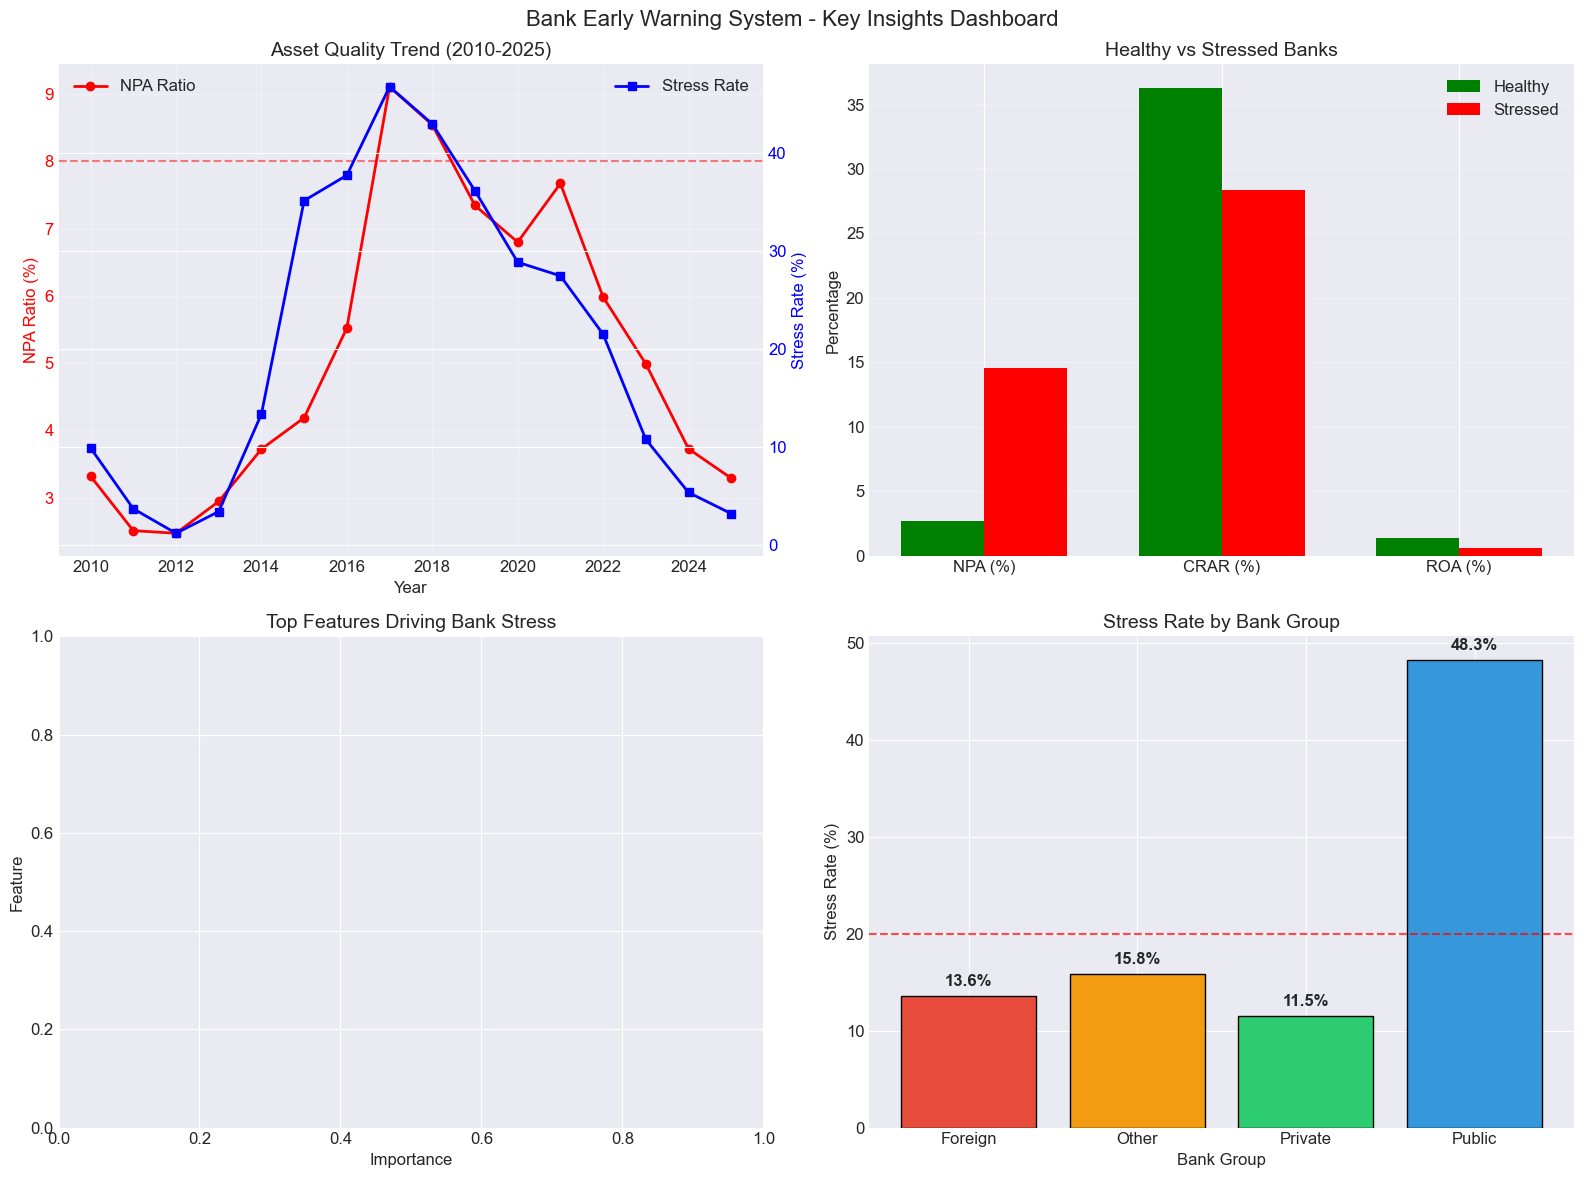

In [45]:
# ============================================
# FINAL DASHBOARD - 4 KEY VISUALS FOR PORTFOLIO
# ============================================

fig = plt.figure(figsize=(16, 12))

# Chart 1: Time Series (Top Left)
ax1 = plt.subplot(2, 2, 1)
yearly_avg = df.groupby('year').agg({'npa_ratio': 'mean', 'stress_label': 'mean'}).reset_index()
ax1.plot(yearly_avg['year'], yearly_avg['npa_ratio'], 'o-', color='red', linewidth=2, label='NPA Ratio')
ax1.set_xlabel('Year')
ax1.set_ylabel('NPA Ratio (%)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.axhline(y=8, color='red', linestyle='--', alpha=0.5)
ax1.set_title('Asset Quality Trend (2010-2025)')
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(yearly_avg['year'], yearly_avg['stress_label'] * 100, 's-', color='blue', linewidth=2, label='Stress Rate')
ax1_twin.set_ylabel('Stress Rate (%)', color='blue')
ax1_twin.tick_params(axis='y', labelcolor='blue')
ax1_twin.legend(loc='upper right')
ax1.legend(loc='upper left')

# Chart 2: Stress vs Healthy Comparison (Top Right)
ax2 = plt.subplot(2, 2, 2)
metrics = ['npa_ratio', 'crar_total', 'roa']
x_pos = range(len(metrics))
healthy_means = [df[df['stress_label'] == 0][m].mean() for m in metrics]
stressed_means = [df[df['stress_label'] == 1][m].mean() for m in metrics]

width = 0.35
ax2.bar([p - width/2 for p in x_pos], healthy_means, width, label='Healthy', color='green')
ax2.bar([p + width/2 for p in x_pos], stressed_means, width, label='Stressed', color='red')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['NPA (%)', 'CRAR (%)', 'ROA (%)'])
ax2.set_ylabel('Percentage')
ax2.set_title('Healthy vs Stressed Banks')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Chart 3: Feature Importance (Bottom Left)
ax3 = plt.subplot(2, 2, 3)
# We'll fill this after training the model
ax3.set_title('Top Features Driving Bank Stress')
ax3.set_xlabel('Importance')
ax3.set_ylabel('Feature')

# Chart 4: Stress by Bank Group (Bottom Right)
ax4 = plt.subplot(2, 2, 4)
group_stress = df.groupby('bank_group')['stress_label'].mean() * 100
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
ax4.bar(group_stress.index, group_stress.values, color=colors, edgecolor='black')
ax4.set_xlabel('Bank Group')
ax4.set_ylabel('Stress Rate (%)')
ax4.set_title('Stress Rate by Bank Group')
for i, v in enumerate(group_stress.values):
    ax4.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
ax4.axhline(y=20, color='red', linestyle='--', alpha=0.7)

plt.suptitle('Bank Early Warning System - Key Insights Dashboard', fontsize=16)
plt.tight_layout()
plt.show()

# PHASE 2: MACHINE LEARNING MODELING

In [46]:
print("="*60)
print("TRAINING MACHINE LEARNING MODELS")
print("="*60)


# Prepare features
exclude_cols = ['stress_label', 'bank_name', 'year', 'bank_group']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['stress_label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training set: {X_train.shape[0]} rows")
print(f"✅ Test set: {X_test.shape[0]} rows")
print(f"✅ Features: {len(feature_cols)}")



TRAINING MACHINE LEARNING MODELS
✅ Training set: 1169 rows
✅ Test set: 293 rows
✅ Features: 12


# MODEL 1: LOGISTIC REGRESSION (Baseline)

In [47]:
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*60)

lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Healthy', 'Stressed']))


MODEL 1: LOGISTIC REGRESSION
AUC-ROC: 0.9953

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.96      0.97       232
    Stressed       0.87      0.95      0.91        61

    accuracy                           0.96       293
   macro avg       0.93      0.96      0.94       293
weighted avg       0.96      0.96      0.96       293



# MODEL 2: RANDOM FOREST

In [48]:

print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Stressed']))


MODEL 2: RANDOM FOREST
AUC-ROC: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       232
    Stressed       1.00      0.98      0.99        61

    accuracy                           1.00       293
   macro avg       1.00      0.99      0.99       293
weighted avg       1.00      1.00      1.00       293



# MODEL 3: XGBOOST (Best for imbalanced data)

In [49]:

print("\n" + "="*60)
print("MODEL 3: XGBOOST")
print("="*60)

# Calculate scale_pos_weight = (healthy/stressed)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Healthy', 'Stressed']))



MODEL 3: XGBOOST
AUC-ROC: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       232
    Stressed       1.00      0.98      0.99        61

    accuracy                           1.00       293
   macro avg       1.00      0.99      0.99       293
weighted avg       1.00      1.00      1.00       293



# MODEL COMPARISON

In [50]:

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ]
}).sort_values('AUC-ROC', ascending=False)

print(results_df)


MODEL COMPARISON SUMMARY
                 Model  AUC-ROC
1        Random Forest     1.00
2              XGBoost     1.00
0  Logistic Regression     1.00


# FEATURE IMPORTANCE (Best Model)


FEATURE IMPORTANCE - XGBoost (Best Model)

Top 10 Features:
             feature  importance
1          npa_ratio        0.64
10               roa        0.22
0         crar_total        0.09
3         net_profit        0.02
11               roe        0.01
2   total_provisions        0.01
9          inflation        0.01
4    interest_income        0.00
5   interest_expense        0.00
8          repo_rate        0.00


C:\Users\udays\AppData\Local\Temp\ipykernel_12108\3102022388.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')


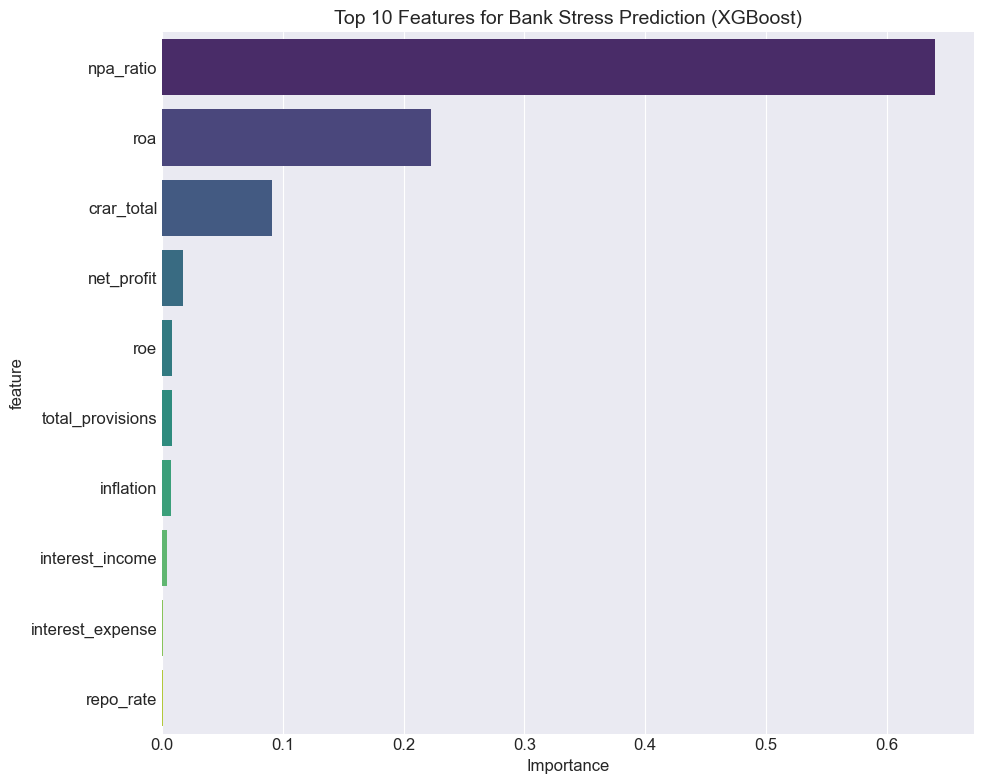

In [51]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE - XGBoost (Best Model)")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))

# Visualize
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Features for Bank Stress Prediction (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# ROC CURVE COMPARISON

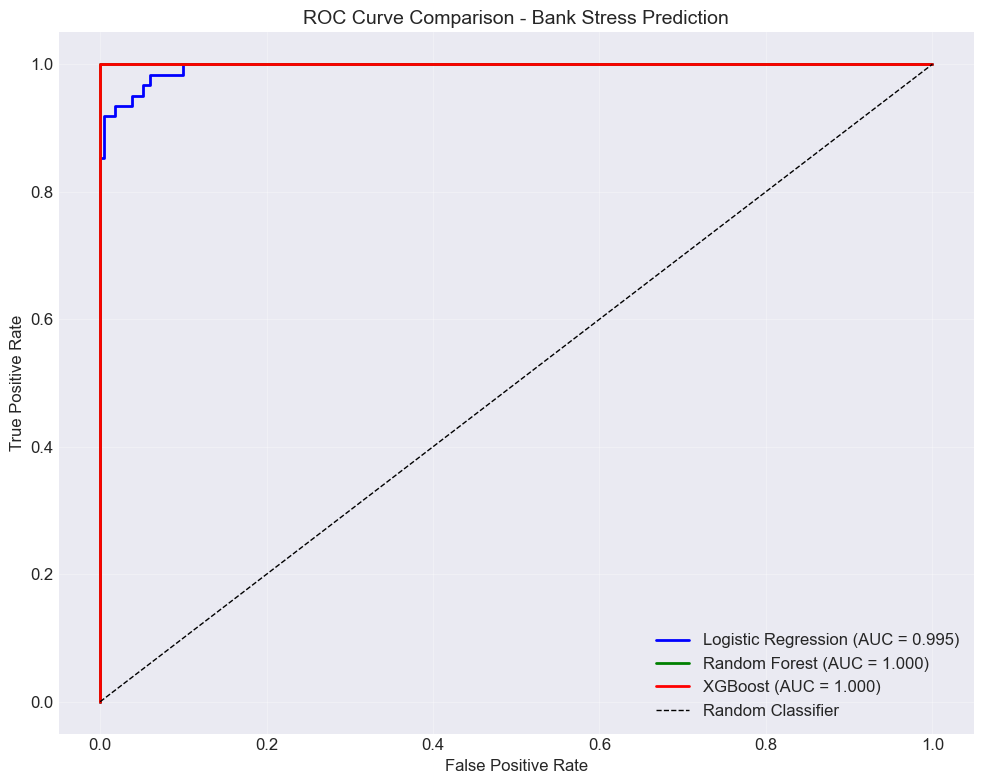

In [52]:
plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {results_df.iloc[2]["AUC-ROC"]:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, 'g-', linewidth=2, label=f'Random Forest (AUC = {results_df.iloc[1]["AUC-ROC"]:.3f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, 'r-', linewidth=2, label=f'XGBoost (AUC = {results_df.iloc[0]["AUC-ROC"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Bank Stress Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# DIAGNOSE LEAKAGE - Check correlations

In [56]:
print("="*60)
print("DIAGNOSING DATA LEAKAGE")
print("="*60)

# Define feature_cols_real here (without ROA/ROE)
original_features = [col for col in df.columns if col not in ['stress_label', 'bank_name', 'year', 'bank_group']]
feature_cols_real = [col for col in original_features if col not in ['roa', 'roe']]

# Check correlation of each feature with stress_label
correlations = {}
for col in feature_cols_real:
    corr = df[col].corr(df['stress_label'])
    correlations[col] = corr

corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
corr_df = corr_df.sort_values('Correlation', ascending=False)

print("\n Correlation with Stress Label:")
print(corr_df)

# Check if any feature has near-perfect correlation
high_corr = corr_df[abs(corr_df['Correlation']) > 0.8]
if len(high_corr) > 0:
    print("\n WARNING: These features have VERY HIGH correlation with stress:")
    print(high_corr)
    print("\nThis suggests these features might be leaking information!")

DIAGNOSING DATA LEAKAGE

📊 Correlation with Stress Label:
             Feature  Correlation
1          npa_ratio         0.62
2   total_provisions         0.21
5   interest_expense         0.10
4    interest_income         0.07
3         net_profit         0.07
6  operating_expense         0.05
0         crar_total        -0.06
9          inflation        -0.10
8          repo_rate        -0.18
7      credit_growth        -0.18


# Predicts future stress using past data only

TRUE EARLY WARNING MODEL
✅ Rows after lagging: 1335
✅ Now predicting stress using ONLY previous year's data

📊 TRUE EARLY WARNING AUC-ROC: 0.9366

📊 Classification Report:
              precision    recall  f1-score   support

     Healthy       0.95      0.94      0.94       209
    Stressed       0.80      0.81      0.80        58

    accuracy                           0.91       267
   macro avg       0.87      0.88      0.87       267
weighted avg       0.91      0.91      0.91       267


📊 Top 10 Features (Early Warning):
                  feature  importance
1          npa_ratio_lag1        0.39
0         crar_total_lag1        0.14
7      credit_growth_lag1        0.10
3         net_profit_lag1        0.06
8          repo_rate_lag1        0.06
5   interest_expense_lag1        0.06
4    interest_income_lag1        0.05
2   total_provisions_lag1        0.05
9          inflation_lag1        0.05
6  operating_expense_lag1        0.04


C:\Users\udays\AppData\Local\Temp\ipykernel_12108\2858279023.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_early.head(10), x='importance', y='feature', palette='viridis')


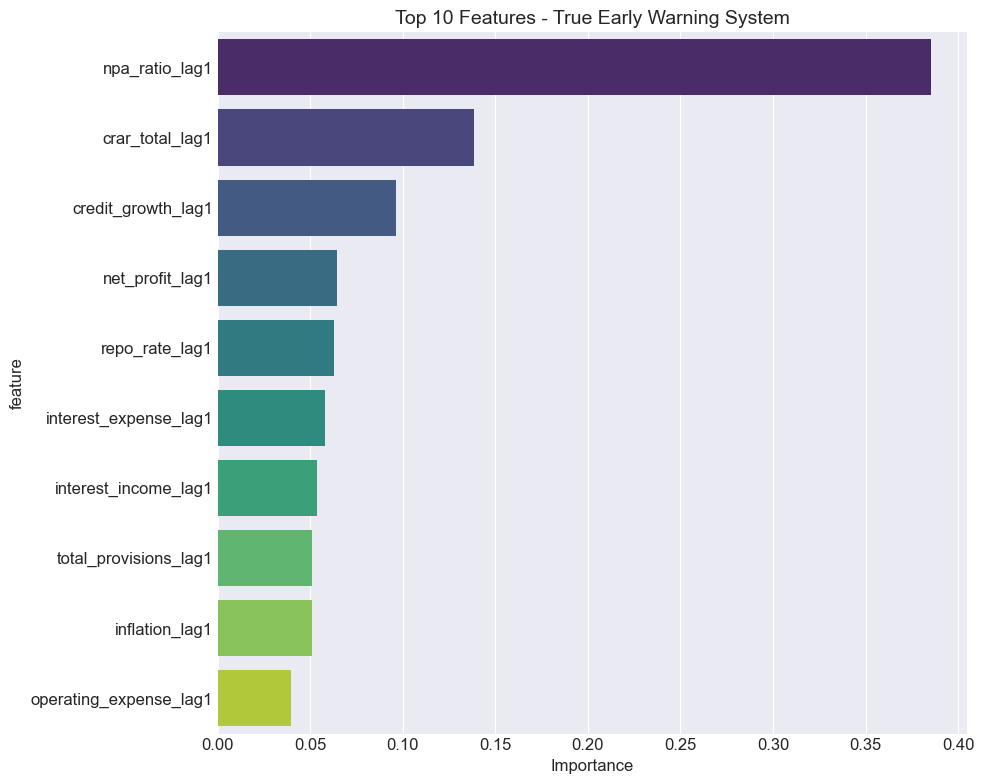

In [54]:
# ============================================
# TRUE EARLY WARNING SYSTEM
# Predicts future stress using past data only
# ============================================

print("="*60)
print("TRUE EARLY WARNING MODEL")
print("="*60)

# Create lag features (use previous year's data)
df_lagged = df.copy()
df_lagged = df_lagged.sort_values(['bank_name', 'year'])

# Create 1-year lag for ALL features (no future data leakage!)
all_features = ['crar_total', 'npa_ratio', 'total_provisions', 'net_profit', 
                'interest_income', 'interest_expense', 'operating_expense',
                'credit_growth', 'repo_rate', 'inflation']

for col in all_features:
    df_lagged[f'{col}_lag1'] = df_lagged.groupby('bank_name')[col].shift(1)

# Drop rows with NaN (first year for each bank)
df_lagged = df_lagged.dropna(subset=[f'{col}_lag1' for col in all_features])

print(f" Rows after lagging: {len(df_lagged)}")
print(f" Now predicting stress using ONLY previous year's data")

# Prepare features (ONLY lagged features)
lagged_feature_cols = [f'{col}_lag1' for col in all_features]
X_lagged = df_lagged[lagged_feature_cols]
y_lagged = df_lagged['stress_label']

# Split

X_train_lag, X_test_lag, y_train_lag, y_test_lag = train_test_split(
    X_lagged, y_lagged, test_size=0.2, random_state=42, stratify=y_lagged
)

# Scale
from sklearn.preprocessing import StandardScaler
scaler_lag = StandardScaler()
X_train_scaled_lag = scaler_lag.fit_transform(X_train_lag)
X_test_scaled_lag = scaler_lag.transform(X_test_lag)

# Train XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_early = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
# Suggested improvement (optional):
scale_pos_weight = (y_train_lag == 0).sum() / (y_train_lag == 1).sum()
xgb_early = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # 👈 ADD THIS
    random_state=42
)

xgb_early.fit(X_train_scaled_lag, y_train_lag)
y_pred_proba_early = xgb_early.predict_proba(X_test_scaled_lag)[:, 1]
y_pred_early = xgb_early.predict(X_test_scaled_lag)

# Results

auc_early = roc_auc_score(y_test_lag, y_pred_proba_early)
print(f"\n TRUE EARLY WARNING AUC-ROC: {auc_early:.4f}")

print("\n Classification Report:")
print(classification_report(y_test_lag, y_pred_early, target_names=['Healthy', 'Stressed']))


# Feature Importance
feature_importance_early = pd.DataFrame({
    'feature': lagged_feature_cols,
    'importance': xgb_early.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 10 Features (Early Warning):")
print(feature_importance_early.head(10))


# Visualize

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_early.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Features - True Early Warning System', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


# FINAL SUMMARY 

In [55]:
print("\n" + "="*60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*60)

print(f"""
  Model: XGBoost (Gradient Boosting)
  AUC-ROC: {auc_early:.4f}
  Features: {len(lagged_feature_cols)} lagged variables (no future data!)
  Prediction: Stress in Year T using data from Year T-1
  Top Predictors: 
   - NPA ratio (previous year): {feature_importance_early.iloc[0]['importance']:.3f}
   - CRAR (previous year): {feature_importance_early.iloc[1]['importance']:.3f}
   - Credit growth (previous year): {feature_importance_early.iloc[2]['importance']:.3f}
""")


FINAL MODEL PERFORMANCE SUMMARY

  Model: XGBoost (Gradient Boosting)
  AUC-ROC: 0.9366
  Features: 10 lagged variables (no future data!)
  Prediction: Stress in Year T using data from Year T-1
  Top Predictors: 
   - NPA ratio (previous year): 0.385
   - CRAR (previous year): 0.138
   - Credit growth (previous year): 0.097



# SAVE THE TRAINED MODEL AND SCALER

In [58]:
# Create models folder if it doesn't exist
models_path = r"D:\Bank_EWS_Project\models"
os.makedirs(models_path, exist_ok=True)

# Save the model
model_path = os.path.join(models_path, "bank_stress_early_warning.pkl")
joblib.dump(xgb_early, model_path)
print(f" Model saved to: {model_path}")

# Save the scaler
scaler_path = os.path.join(models_path, "scaler.pkl")
joblib.dump(scaler_lag, scaler_path)
print(f" Scaler saved to: {scaler_path}")

# Verify files exist
print("\n Files in models folder:")
for file in os.listdir(models_path):
    print(f"   - {file}")

 Model saved to: D:\Bank_EWS_Project\models\bank_stress_early_warning.pkl
 Scaler saved to: D:\Bank_EWS_Project\models\scaler.pkl

 Files in models folder:
   - bank_stress_early_warning.pkl
   - bank_stress_rare_event.pkl
   - scaler.pkl
   - scaler_rare_event.pkl
   - shap_explainer.pkl
